<a href="https://colab.research.google.com/github/devanshRaana/PS-/blob/main/PS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile


In [56]:
ZIP_FILE_LOCATION = "/content/mnist-dataset.zip"
TARGET_EXTRACTION_DIR = "/content/mnist"

import os
import zipfile

# Check if the zip file exists at the specified location
if not os.path.exists(ZIP_FILE_LOCATION):
    print(f"Error: Dataset zip archive not found at '{ZIP_FILE_LOCATION}'.")
    print("Please ensure 'mnist-dataset.zip' is uploaded to '/content/' or update 'ZIP_FILE_LOCATION' variable with the correct path.")
else:
    try:
        # Attempt to extract the archive contents
        with zipfile.ZipFile(ZIP_FILE_LOCATION, "r") as archive_handle:
            archive_handle.extractall(TARGET_EXTRACTION_DIR)

        print("MNIST dataset successfully extracted.")

        # Verify extracted contents by listing files in the target directory
        if os.path.exists(TARGET_EXTRACTION_DIR) and os.listdir(TARGET_EXTRACTION_DIR):
            print(f"Contents of extracted directory '{TARGET_EXTRACTION_DIR}':")
            for entry_name in os.listdir(TARGET_EXTRACTION_DIR):
                print(f"- {entry_name}")
        else:
            print(f"Warning: Extraction directory '{TARGET_EXTRACTION_DIR}' is empty or not found after extraction.")
            print("This might indicate an issue with the zip file or the extraction process.")
    except zipfile.BadZipFile:
        print(f"Error: The file '{ZIP_FILE_LOCATION}' is not a valid zip archive.")
        print("Please upload a correct and uncorrupted 'mnist-dataset.zip' file.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")

MNIST dataset successfully extracted.
Contents of extracted directory '/content/mnist':
- train-images.idx3-ubyte
- train-images-idx3-ubyte
- t10k-images-idx3-ubyte
- train-labels-idx1-ubyte
- t10k-labels-idx1-ubyte
- t10k-labels.idx1-ubyte
- t10k-images.idx3-ubyte
- train-labels.idx1-ubyte


In [57]:
def load_images(filepath):
  with open(filepath, "rb") as data_file:
    _ = int.from_bytes(data_file.read(4), "big")  # Magic number
    num_data_items = int.from_bytes(data_file.read(4), "big")
    image_rows = int.from_bytes(data_file.read(4), "big")
    image_cols = int.from_bytes(data_file.read(4), "big")

    raw_pixel_data = np.frombuffer(
        data_file.read(),
        dtype = np.uint8
    )
    reshaped_image_array = raw_pixel_data.reshape(num_data_items, image_rows, image_cols)
    return reshaped_image_array

def load_labels(filepath):
  with open(filepath, "rb") as data_file:
    _ = int.from_bytes(data_file.read(4), "big")  # Magic number
    num_label_items = int.from_bytes(data_file.read(4), "big")

    raw_label_data = np.frombuffer(
        data_file.read(),
        dtype = np.uint8
    )
    return raw_label_data

In [58]:
mnist_base_path = "/content/mnist"

training_images = load_images(f"{mnist_base_path}/train-images.idx3-ubyte")
training_labels = load_labels(f"{mnist_base_path}/train-labels.idx1-ubyte")

testing_images = load_images(f"{mnist_base_path}/t10k-images.idx3-ubyte")
testing_labels = load_labels(f"{mnist_base_path}/t10k-labels.idx1-ubyte")

print(f"Training image data shape: {training_images.shape}")
print(f"Training label data shape: {training_labels.shape}")

print(f"Testing image data shape: {testing_images.shape}")
print(f"Testing label data shape: {testing_labels.shape}")

Training image data shape: (60000, 28, 28)
Training label data shape: (60000,)
Testing image data shape: (10000, 28, 28)
Testing label data shape: (10000,)


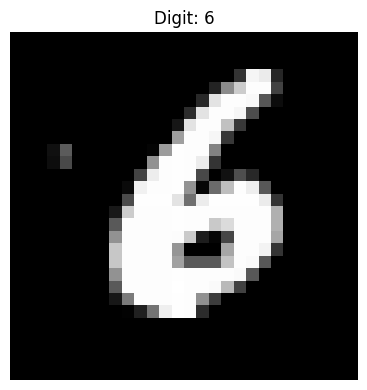

In [59]:
import random
plt.figure(figsize=(4,4))
sample_index = random.randint(0, len(training_images) - 1)

plt.imshow(training_images[sample_index], cmap="gray")
plt.title(f"Digit: {training_labels[sample_index]}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [60]:
print(f"Training image data dimensions: {training_images.shape}")
print(f"Training label data dimensions: {training_labels.shape}")

print(f"Image pixel value range: Min = {training_images.min()}, Max = {training_images.max()}")

print(f"Image data type: {training_images.dtype}")

print(f"Unique labels observed in training set: {np.unique(training_labels)}")

Training image data dimensions: (60000, 28, 28)
Training label data dimensions: (60000,)
Image pixel value range: Min = 0, Max = 255
Image data type: uint8
Unique labels observed in training set: [0 1 2 3 4 5 6 7 8 9]


In [61]:
distinct_labels, label_counts = np.unique(training_labels, return_counts=True)

print("Distribution of training dataset labels:")
for label_value, frequency in zip(distinct_labels, label_counts):
    print(f"Digit {label_value}: {frequency} samples")

print(f"\nSample training image (index {sample_index}):")
print(training_images[sample_index])
print(f"Corresponding label: {training_labels[sample_index]}")

Distribution of training dataset labels:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Sample training image (index 38555):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   51 245 235  38   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  35 139
  204 253 253  66   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  40 228 253
  253 249  87  12   0   0   0   0   0   0]

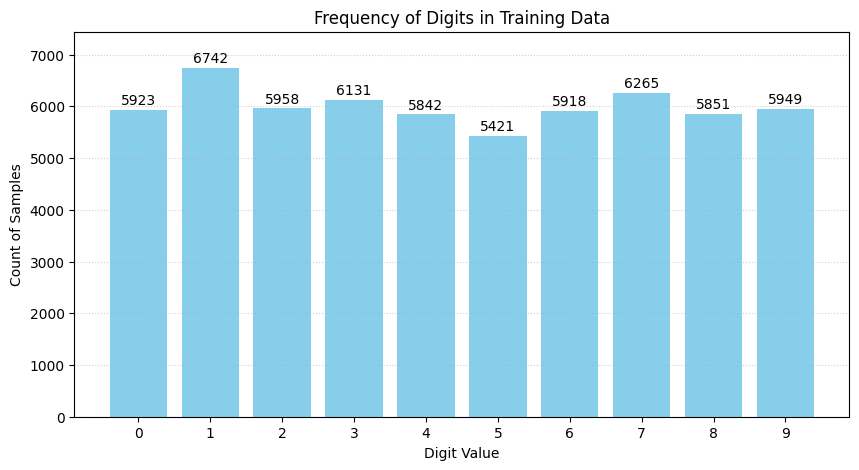

In [62]:
plt.figure(figsize=(10, 5))
plot_bars = plt.bar(distinct_labels, label_counts, color='skyblue')

plt.title("Frequency of Digits in Training Data")
plt.xlabel("Digit Value")
plt.ylabel("Count of Samples")

plt.xticks(distinct_labels)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for single_bar in plot_bars:
    bar_height = single_bar.get_height()
    plt.text(
        single_bar.get_x() + single_bar.get_width() / 2,
        bar_height + 50,  # Adding a small offset for distinction
        str(bar_height),
        ha='center',
        va='bottom'
    )

plt.ylim(0, max(label_counts) + 700) # Adjust y-limit for text visibility
plt.show()

In [63]:
flat_training_data = training_images.reshape(training_images.shape[0], -1)
flat_testing_data = testing_images.reshape(testing_images.shape[0], -1)

print(f"Shape of flattened training images: {flat_training_data.shape}")
print(f"Shape of flattened testing images: {flat_testing_data.shape}")
print(f"Shape of training labels: {training_labels.shape}")
print(f"Shape of testing labels: {testing_labels.shape}\n")

flat_training_data = flat_training_data.astype(np.float32) / 255.0
flat_testing_data = flat_testing_data.astype(np.float32) / 255.0

print(f"Normalized training data pixel range: Min={flat_training_data.min()}, Max={flat_training_data.max()}")
print(f"Normalized testing data pixel range: Min={flat_testing_data.min()}, Max={flat_testing_data.max()}")

Shape of flattened training images: (60000, 784)
Shape of flattened testing images: (10000, 784)
Shape of training labels: (60000,)
Shape of testing labels: (10000,)

Normalized training data pixel range: Min=0.0, Max=1.0
Normalized testing data pixel range: Min=0.0, Max=1.0


In [33]:
def one_hot_encode(labels, num_classes=10):

  encoded = np.zeros(
      (labels.size, num_classes)
  )
  encoded[
        np.arange(labels.size),
        labels
  ] = 1

  return encoded

In [64]:
encoded_training_labels = one_hot_encode(training_labels)
encoded_testing_labels = one_hot_encode(testing_labels)

print(f"Original label for sample index {sample_index}: {training_labels[sample_index]}")
print(f"One-hot encoded label for sample index {sample_index}: {encoded_training_labels[sample_index]}")
print(f"Shape of encoded training labels: {encoded_training_labels.shape}")

Original label for sample index 38555: 6
One-hot encoded label for sample index 38555: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Shape of encoded training labels: (60000, 10)


In [65]:
np.random.seed(42)

# Generate random indices for shuffling the training data
shuffle_indices = np.random.permutation(flat_training_data.shape[0])

# Apply shuffling to both training images and labels
shuffled_training_images = flat_training_data[shuffle_indices]
shuffled_encoded_labels = encoded_training_labels[shuffle_indices]

validation_sample_count = 6000

# Split the data into training and validation sets
validation_images = shuffled_training_images[:validation_sample_count]
validation_labels = shuffled_encoded_labels[:validation_sample_count]

final_training_images = shuffled_training_images[validation_sample_count:]
final_training_labels = shuffled_encoded_labels[validation_sample_count:]

print("--- Dataset Split Shapes ---")
print(f"Final training images shape: {final_training_images.shape}")
print(f"Final training labels shape: {final_training_labels.shape}")

print(f"\nValidation images shape: {validation_images.shape}")
print(f"Validation labels shape: {validation_labels.shape}")

print(f"\nTest images shape: {flat_testing_data.shape}")
print(f"Test labels shape: {encoded_testing_labels.shape}")

--- Dataset Split Shapes ---
Final training images shape: (54000, 784)
Final training labels shape: (54000, 10)

Validation images shape: (6000, 784)
Validation labels shape: (6000, 10)

Test images shape: (10000, 784)
Test labels shape: (10000, 10)


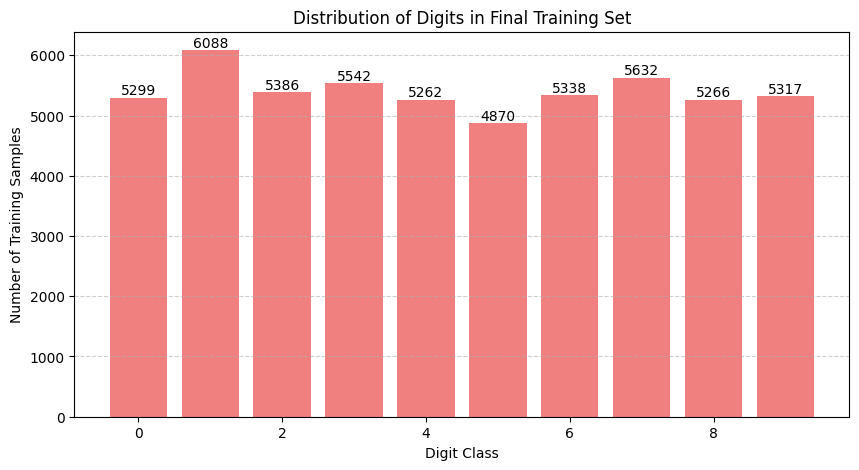

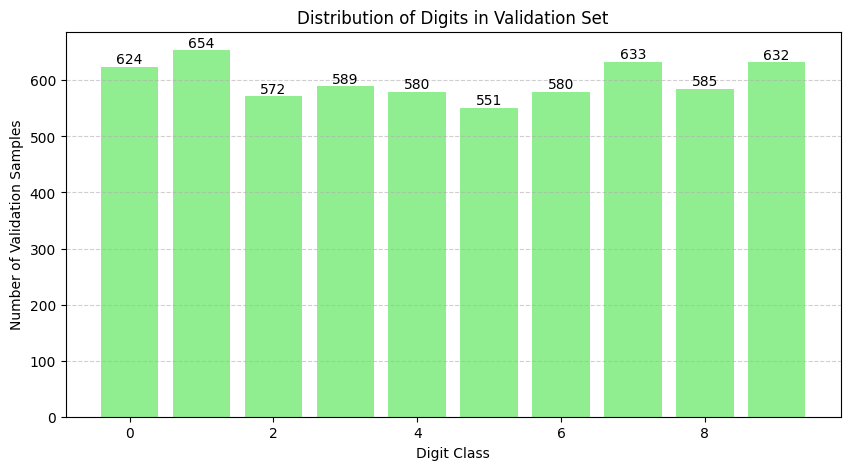

In [66]:
decoded_training_labels = np.argmax(final_training_labels, axis=1)

distinct_train_digits, train_counts = np.unique(decoded_training_labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(distinct_train_digits, train_counts, color='lightcoral')

plt.title("Distribution of Digits in Final Training Set")
plt.xlabel("Digit Class")
plt.ylabel("Number of Training Samples")

for digit, count in zip(distinct_train_digits, train_counts):
    plt.text(digit, count, str(count),
             ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

decoded_validation_labels = np.argmax(validation_labels, axis=1)

distinct_val_digits, val_counts = np.unique(decoded_validation_labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(distinct_val_digits, val_counts, color='lightgreen')

plt.title("Distribution of Digits in Validation Set")
plt.xlabel("Digit Class")
plt.ylabel("Number of Validation Samples")

for digit, count in zip(distinct_val_digits, val_counts):
    plt.text(digit, count, str(count),
             ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [67]:
input_layer_size = 784
hidden_layer1_size = 128
hidden_layer2_size = 64
output_layer_size = 10

print(f"Input Layer Neurons: {input_layer_size}")
print(f"Hidden Layer 1 Neurons: {hidden_layer1_size}")
print(f"Hidden Layer 2 Neurons: {hidden_layer2_size}")
print(f"Output Layer Neurons: {output_layer_size}")

def setup_network_parameters():
    np.random.seed(42)

    # Weights for Layer 1 (Input to Hidden 1)
    W1 = np.random.randn(input_layer_size, hidden_layer1_size) * np.sqrt(2.0 / input_layer_size)
    b1 = np.zeros((1, hidden_layer1_size))

    # Weights for Layer 2 (Hidden 1 to Hidden 2)
    W2 = np.random.randn(hidden_layer1_size, hidden_layer2_size) * np.sqrt(2.0 / hidden_layer1_size)
    b2 = np.zeros((1, hidden_layer2_size))

    # Weights for Layer 3 (Hidden 2 to Output)
    W3 = np.random.randn(hidden_layer2_size, output_layer_size) * np.sqrt(2.0 / hidden_layer2_size)
    b3 = np.zeros((1, output_layer_size))

    parameters = {
        "W1": W1, "b1": b1,
        "W2": W2, "b2": b2,
        "W3": W3, "b3": b3
    }
    return parameters

Input Layer Neurons: 784
Hidden Layer 1 Neurons: 128
Hidden Layer 2 Neurons: 64
Output Layer Neurons: 10


In [68]:
network_parameters = setup_network_parameters()

print(f"Shape of W1: {network_parameters['W1'].shape}")
print(f"Shape of b1: {network_parameters['b1'].shape}")

print(f"Shape of W2: {network_parameters['W2'].shape}")
print(f"Shape of b2: {network_parameters['b2'].shape}")

print(f"Shape of W3: {network_parameters['W3'].shape}")
print(f"Shape of b3: {network_parameters['b3'].shape}")

Shape of W1: (784, 128)
Shape of b1: (1, 128)
Shape of W2: (128, 64)
Shape of b2: (1, 64)
Shape of W3: (64, 10)
Shape of b3: (1, 10)


In [69]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# Test Softmax function
sample_input_for_softmax = np.array([[2.1, 1.4, 5.9]])
sample_output_softmax = softmax(sample_input_for_softmax)

print(f"Softmax output for sample input: {sample_output_softmax}")
print(f"Sum of Softmax output probabilities: {np.sum(sample_output_softmax)}")

Softmax output for sample input: [[0.02164607 0.01074912 0.96760481]]
Sum of Softmax output probabilities: 1.0


In [70]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3
    }

    return A3, cache

In [41]:
X_sample = X_train_final[:5]

predictions,cache = forward_propagation(
    X_sample,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

print(predictions.shape)
print(predictions[0])
print(np.sum(predictions[0]))
print(np.max(predictions[0]))
predicted_digit = np.argmax(predictions[0])
print(predicted_digit)

(5, 10)
[0.06902082 0.09690726 0.10093865 0.11921127 0.12285651 0.11908683
 0.09956115 0.10204891 0.07816148 0.09220713]
1.0000000000000002
0.12285650893789454
4


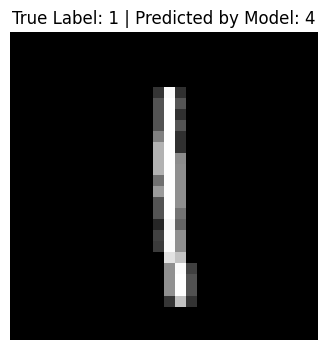

Prediction Analysis for Sample Index 0:
  True Digit: 1
  Model's Top Prediction: 4
  Confidence Scores for each Digit:
    Digit 0: 0.0690
    Digit 1: 0.0969
    Digit 2: 0.1009
    Digit 3: 0.1192
    Digit 4: 0.1229
    Digit 5: 0.1191
    Digit 6: 0.0996
    Digit 7: 0.1020
    Digit 8: 0.0782
    Digit 9: 0.0922


In [71]:
sample_display_idx = 0

# Retrieve the actual label for the specific sample from the original training set's final labels
ground_truth_label = np.argmax(y_train_final[sample_display_idx])

# Retrieve the predicted label from the model's output for the sample
model_predicted_label = np.argmax(predictions[sample_display_idx])

# Get the probability distribution for the sample
prediction_probabilities = predictions[sample_display_idx]

plt.figure(figsize=(4, 4))
plt.imshow(X_sample[sample_display_idx].reshape(28, 28), cmap='gray')

plt.title(
    f"True Label: {ground_truth_label} | Predicted by Model: {model_predicted_label}"
)

plt.axis("off")
plt.show()

# Display detailed prediction information
print(f"Prediction Analysis for Sample Index {sample_display_idx}:")
print(f"  True Digit: {ground_truth_label}")
print(f"  Model's Top Prediction: {model_predicted_label}")
print("  Confidence Scores for each Digit:")
for digit, score in enumerate(prediction_probabilities):
    print(f"    Digit {digit}: {score:.4f}")

In [43]:
def compute_loss(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.sum(
        y_true * np.log(y_pred)
    ) / y_true.shape[0]

    return loss

In [44]:
good_prediction = np.array([
    [0.01,0.01,0.90,0.01,0.01,
     0.01,0.01,0.01,0.01,0.02]
])

true_label = np.array([
    [0,0,1,0,0,0,0,0,0,0]
])

print(
    compute_loss(
        true_label,
        good_prediction
    )
)
bad_prediction = np.array([
    [0.70,0.10,0.02,0.05,0.02,
     0.03,0.02,0.02,0.02,0.02]
])

print(
    compute_loss(
        true_label,
        bad_prediction
    )
)

0.10536051565782628
3.912023005428146


In [45]:
loss = compute_loss(
    y_train_final[:5],
    predictions
)

print(loss)

2.399588908081047


In [73]:
def calculate_backprop_gradients(input_features, actual_labels, network_weights_biases, activation_storage):
    data_points = input_features.shape[0]

    activation_hidden1 = activation_storage["A1"]
    activation_hidden2 = activation_storage["A2"]
    activation_output = activation_storage["A3"]

    pre_activation_hidden1 = activation_storage["Z1"]
    pre_activation_hidden2 = activation_storage["Z2"]

    weights_layer1 = network_weights_biases["W1"]
    weights_layer2 = network_weights_biases["W2"]
    weights_layer3 = network_weights_biases["W3"]

    error_output = activation_output - actual_labels

    grad_W3 = (activation_hidden2.T @ error_output) / data_points
    grad_b3 = np.sum(error_output, axis=0, keepdims=True) / data_points

    error_activation_2 = error_output @ weights_layer3.T
    error_pre_activation_2 = error_activation_2 * relu_derivative(pre_activation_hidden2)

    grad_W2 = (activation_hidden1.T @ error_pre_activation_2) / data_points
    grad_b2 = np.sum(error_pre_activation_2, axis=0, keepdims=True) / data_points

    error_activation_1 = error_pre_activation_2 @ weights_layer2.T
    error_pre_activation_1 = error_activation_1 * relu_derivative(pre_activation_hidden1)

    grad_W1 = (input_features.T @ error_pre_activation_1) / data_points
    grad_b1 = np.sum(error_pre_activation_1, axis=0, keepdims=True) / data_points

    calculated_gradients = {
        "dW1": grad_W1, "db1": grad_b1,
        "dW2": grad_W2, "db2": grad_b2,
        "dW3": grad_W3, "db3": grad_b3
    }

    return calculated_gradients

In [47]:
def update_parameters(
    W1,b1,
    W2,b2,
    W3,b3,
    gradients,
    learning_rate
):

    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]

    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

    W3 -= learning_rate * gradients["dW3"]
    b3 -= learning_rate * gradients["db3"]

    return W1,b1,W2,b2,W3,b3

In [48]:
def train(
    X,
    Y,
    W1,b1,
    W2,b2,
    W3,b3,
    epochs,
    learning_rate,
    batch_size
):

    loss_history = []

    m = X.shape[0]

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]
        Y_shuffled = Y[indices]

        epoch_loss = 0

        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            predictions, cache = forward_propagation(
                X_batch,
                W1,b1,
                W2,b2,
                W3,b3
            )

            loss = compute_loss(
                Y_batch,
                predictions
            )

            gradients = backward_propagation(
                X_batch,
                Y_batch,
                W2,
                W3,
                cache
            )

            W1,b1,W2,b2,W3,b3 = update_parameters(
                W1,b1,
                W2,b2,
                W3,b3,
                gradients,
                learning_rate
            )

            epoch_loss += loss

        epoch_loss /= (m // batch_size)

        loss_history.append(epoch_loss)

        if epoch % 10 == 0:

            print(
                f"Epoch {epoch} | Loss = {epoch_loss:.4f}"
            )

    return (
        W1,b1,
        W2,b2,
        W3,b3,
        loss_history
    )

In [49]:
W1,b1,W2,b2,W3,b3,loss_history = train(
    X_train_final,
    y_train_final,
    W1,b1,
    W2,b2,
    W3,b3,
    epochs=100,
    learning_rate=0.01,
    batch_size=128
)

Epoch 0 | Loss = 1.1759
Epoch 10 | Loss = 0.2323
Epoch 20 | Loss = 0.1656
Epoch 30 | Loss = 0.1285
Epoch 40 | Loss = 0.1042
Epoch 50 | Loss = 0.0868
Epoch 60 | Loss = 0.0735
Epoch 70 | Loss = 0.0630
Epoch 80 | Loss = 0.0544
Epoch 90 | Loss = 0.0474


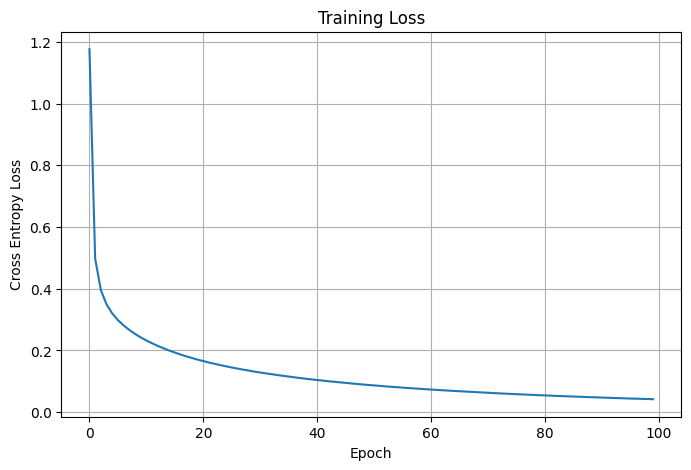

In [50]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

In [51]:
train_predictions, _ = forward_propagation(
    X_train_final,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

train_accuracy = np.mean(
    np.argmax(train_predictions, axis=1)==np.argmax(y_train_final, axis=1)
)

print(f"Training Accuracy: {train_accuracy*100:.2f}%")

Training Accuracy: 99.00%


In [52]:
val_predictions, _ = forward_propagation(
    X_val,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

val_accuracy = np.mean(
    np.argmax(val_predictions, axis=1)
    ==
    np.argmax(y_val, axis=1)
)

print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Validation Accuracy: 97.50%


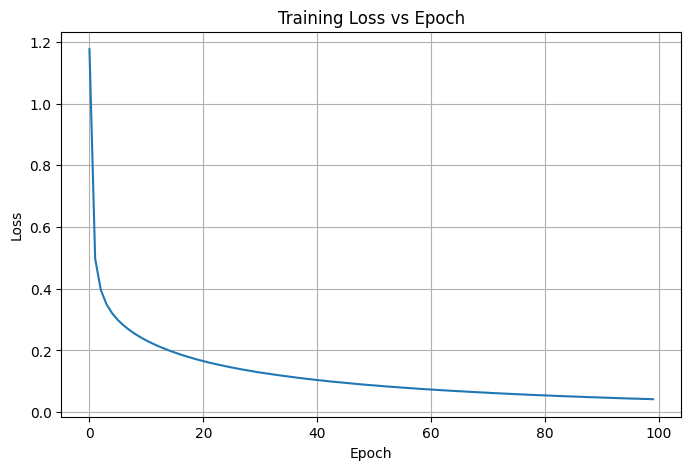

In [53]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [54]:
test_predictions, _ = forward_propagation(
    X_test_flat,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

test_accuracy = np.mean(
    np.argmax(test_predictions, axis=1)
    ==
    np.argmax(y_test_encoded, axis=1)
)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 97.52%


In [55]:
predicted_labels = np.argmax(
    test_predictions,
    axis=1
)

true_labels = np.argmax(
    y_test_encoded,
    axis=1
)

conf_matrix = np.zeros((10,10), dtype=int)

for t, p in zip(true_labels, predicted_labels):
    conf_matrix[t,p] += 1

print(conf_matrix)

[[ 966    0    1    1    1    3    1    3    4    0]
 [   0 1122    4    0    0    0    3    2    4    0]
 [   3    1 1013    2    1    1    1    5    5    0]
 [   0    0    6  990    0    6    0    1    3    4]
 [   1    0    5    0  961    0    2    2    1   10]
 [   3    1    1   13    3  857    5    1    6    2]
 [   4    3    2    1    4    9  933    1    1    0]
 [   0    8    8    3    2    0    0  996    3    8]
 [   3    0    5    7    3    5    3    3  943    2]
 [   4    6    0    6    7    5    1    5    4  971]]
